In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Drop No feature and rename all other features

In [2]:
df = pd.read_excel('../data/realestate.xlsx')

df = df.drop(columns=['No'])
df.columns = [
    'house_age',
    'mrt_distance',
    'convenience_stores',
    'latitude',
    'longitude',
    'price_per_unit'
]

df.head()

,house_age,mrt_distance,convenience_stores,latitude,longitude,price_per_unit
0,32.0,"""84.87882""",100.0,24.98298,121.54024,37.9
1,19.5,"""306.5947""",9.0,24.98034,121.53951,42.2
2,13.3,"""561.9845""",5.0,24.98746,121.54391,47.3
3,13.3,"""561.9845""",5.0,24.98746,121.54391,54.8
4,5.0,"""390.5684""",5.0,24.97937,121.54245,43.1


# Fix MRT data type issue

In [3]:
df['mrt_distance'] = df['mrt_distance'].str.replace('"', '').astype(float)

print("dtype:", df['mrt_distance'].dtype)
df['mrt_distance'].head()

dtype: float64


0     84.87882
1    306.59470
2    561.98450
3    561.98450
4    390.56840
Name: mrt_distance, dtype: float64

# Drop house_age outliers

In [4]:
print("Before:", df.shape)

df = df[df['house_age'] <= 100]

print("\nAfter:", df.shape)

Before: (414, 6)

After: (402, 6)


# Impute missing values

In [5]:
print("Missing before:\n", df.isnull().sum())

df['house_age'] = df['house_age'].fillna(df['house_age'].median())
df['convenience_stores'] = df['convenience_stores'].fillna(df['convenience_stores'].median())

print("\nMissing after:\n", df.isnull().sum())

Missing before:
 house_age             0
mrt_distance          0
convenience_stores    0
latitude              0
longitude             0
price_per_unit        0
dtype: int64

Missing after:
 house_age             0
mrt_distance          0
convenience_stores    0
latitude              0
longitude             0
price_per_unit        0
dtype: int64


# Log transform features

In [6]:
print("Skew before:")
print(f"  mrt_distance:  {df['mrt_distance'].skew():.2f}")
print(f"  house_age:     {df['house_age'].skew():.2f}")

df['mrt_distance_log'] = np.log(df['mrt_distance'])
df['house_age_log'] = np.log1p(df['house_age'])  # log1p handles zeros safely

print("\nSkew after:")
print(f"  mrt_distance_log:  {df['mrt_distance_log'].skew():.2f}")
print(f"  house_age_log:     {df['house_age_log'].skew():.2f}")

df = df.drop(columns=['mrt_distance', 'house_age'])

Skew before:
  mrt_distance:  1.93
  house_age:     0.38

Skew after:
  mrt_distance_log:  0.05
  house_age_log:     -1.26


Below 0.5 — fine as-is

0.5 to 1 — moderate, worth considering a transform

Above 1 — high, transform recommended

# Engineer walkable to MRT Flag

In [7]:
# Properties within 500m of a station command a clear price premium
# (visible as the steep left side of the pairplot decay curve)

# Note: we use the original mrt_distance values stored in mrt_distance_log
# so we need to exponentiate back to check the threshold
df['walkable_mrt'] = (np.exp(df['mrt_distance_log']) <= 500).astype(int)

print("Walkable to MRT breakdown:")
print(df['walkable_mrt'].value_counts())
print(f"\nMean price (walkable):     {df[df['walkable_mrt']==1]['price_per_unit'].mean():.1f}")
print(f"Mean price (not walkable): {df[df['walkable_mrt']==0]['price_per_unit'].mean():.1f}")

Walkable to MRT breakdown:
walkable_mrt
1    205
0    197
Name: count, dtype: int64

Mean price (walkable):     46.2
Mean price (not walkable): 29.6


# Bin Convenience Stores

In [8]:
# Raw count has a suspicious outlier near 100
# Relationship with price isn't cleanly linear — binning is more honest

bins = [-1, 0, 3, 7, float('inf')]
labels = ['none', 'low', 'medium', 'high']

df['convenience_bins'] = pd.cut(df['convenience_stores'], bins=bins, labels=labels)

print(df['convenience_bins'].value_counts().sort_index())
print("\nMean price by bin:")
print(df.groupby('convenience_bins', observed=True)['price_per_unit'].mean().round(1))

df = df.drop(columns=['convenience_stores'])

convenience_bins
none       66
low       113
medium    158
high       64
Name: count, dtype: int64

Mean price by bin:
convenience_bins
none      26.6
low       31.0
medium    43.8
high      48.1
Name: price_per_unit, dtype: float64


# Encode categorical features

In [9]:
# Linear regression needs numeric inputs — one-hot encode the bins
# drop_first=True avoids the dummy variable trap

df = pd.get_dummies(df, columns=['convenience_bins'], drop_first=True)

df.head()

,latitude,longitude,price_per_unit,mrt_distance_log,house_age_log,walkable_mrt,convenience_bins_low,convenience_bins_medium,convenience_bins_high
0,24.98298,121.54024,37.9,4.441225,3.496508,1,False,False,True
1,24.98034,121.53951,42.2,5.725527,3.020425,1,False,False,True
2,24.98746,121.54391,47.3,6.331474,2.660260,0,False,True,False
3,24.98746,121.54391,54.8,6.331474,2.660260,0,False,True,False
4,24.97937,121.54245,43.1,5.967603,1.791759,1,False,True,False


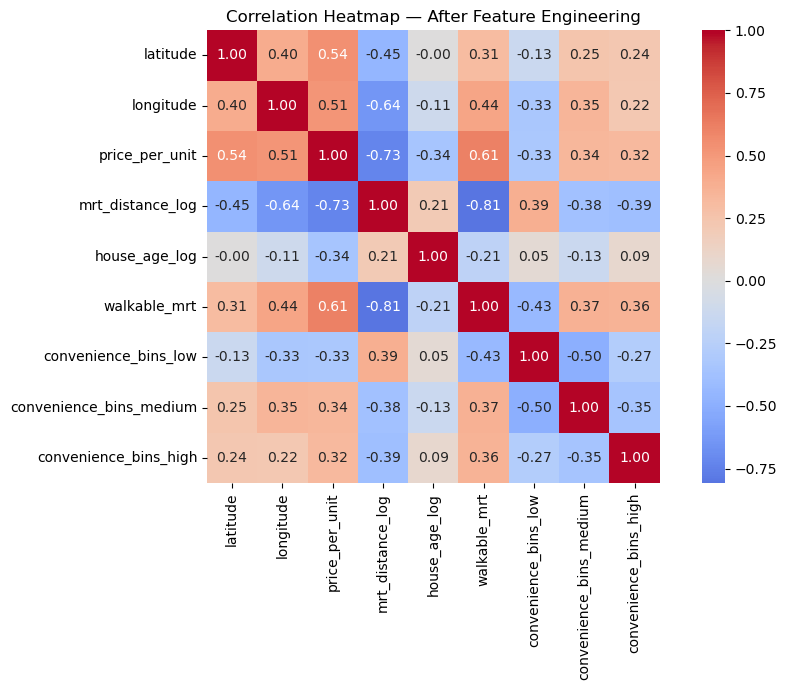


Correlation with target:
 price_per_unit             1.000000
walkable_mrt               0.614137
latitude                   0.544842
longitude                  0.513034
convenience_bins_medium    0.339615
convenience_bins_high      0.322610
convenience_bins_low      -0.325677
house_age_log             -0.341872
mrt_distance_log          -0.729378
Name: price_per_unit, dtype: float64


In [10]:

corr = df.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap — After Feature Engineering')
plt.tight_layout()
plt.show()

print("\nCorrelation with target:\n", corr['price_per_unit'].sort_values(ascending=False))

In [11]:
df = df.drop(columns=['longitude', 'walkable_mrt'])

Since `mrt_distance_log` is a continuous variable that preserves the 
full spectrum of distance information, it is strictly more informative than the 
binary `walkable_mrt` flag. Dropping the binary feature retains all meaningful 
signal while eliminating the redundancy.

Longitude was dropped due to a high correlation of -0.64 with `mrt_distance_log`.

# Final check

In [12]:
print(df.shape)
print(df.isnull().sum())
df.dtypes

(402, 7)
latitude                   0
price_per_unit             0
mrt_distance_log           0
house_age_log              0
convenience_bins_low       0
convenience_bins_medium    0
convenience_bins_high      0
dtype: int64


latitude                   float64
price_per_unit             float64
mrt_distance_log           float64
house_age_log              float64
convenience_bins_low          bool
convenience_bins_medium       bool
convenience_bins_high         bool
dtype: object

In [13]:
df.to_csv('../data/housing_clean.csv', index=False)